<h1>Model Development</h1>

In [2]:
%pip install seaborn

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pyodide.http import pyfetch

<ipython-input-3-cc14ba13cb36>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [9]:
pd.set_option("display.max_columns", None)

In [4]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"
filename = "cars_data.csv"

In [5]:
async def download(url, filename):
    try:
        response = await pyfetch(url)
        if response.status == 200:
            print("Connection to URL successfull")
            with open (filename, "wb") as f:
                f.write(await response.bytes())
                print(f"{filename} successfully written")
    except Exception as e:
        print(f"Error: {e}")

In [6]:
await download(url, filename)

Connection to URL successfull
cars_data.csv successfully written


df = pd.read_csv(filename)
df.head()

<h2>Linear Regression</h2>
<p>Linear Function: <b>Y = a + bX</b></p>

<h5>Effect of highway-mpg on price</h5>

In [84]:
from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()

In [85]:
X = df[["highway-mpg"]]
Y = df["price"]

In [86]:
model_1.fit(X, Y)

LinearRegression()

In [87]:
Y_pred = model_1.predict(X)

In [88]:
Y_pred[0:5]

array([16236.50464347, 16236.50464347, 17058.23802179, 13771.3045085 ,
       20345.17153508])

<h5>Results:</h5>

In [89]:
a = model_1.coef_[0]
b = model_1.intercept_
sign = "+" if a >=0 else ""
print(f"""
Regression coeficient : {a:.2f}
Regression intercept : {b:.2f}
Linear equation : price = {b:.2f} {sign}{a:.2f}(highway-mpg)
""")


Regression coeficient : -821.73
Regression intercept : 38423.31
Linear equation : price = 38423.31 -821.73(highway-mpg)



In [90]:
import statsmodels.api as sm
Xols = sm.add_constant(X) #add intercept column(necessary)
model_2 = sm.OLS(Y,Xols).fit()
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                     196.3
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           1.75e-31
Time:                        21:32:22   Log-Likelihood:                -2020.8
No. Observations:                 201   AIC:                             4046.
Df Residuals:                     199   BIC:                             4052.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3.842e+04   1843.391     20.844      0.000    3.48e+04    4.21e+04
highway-mpg  -821.7334     58.650    -14.011      0.000    -937.388    -706.079
==============================================================================
Omnibus:                       58.855   Durbin-Watson:                   0.852
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              109.474
Skew:                           1.476   Prob(JB):                     1.69e-24
Kurtosis:                       5.088   Cond. No.                         145.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [91]:
f_value = model_2.fvalue
p_model = model_2.f_pvalue
r2 = model_2.rsquared
t_value = model_2.tvalues["highway-mpg"]
beta = model_2.params["highway-mpg"]
ci_low, ci_high = model_2.conf_int().loc["highway-mpg"]

p_text = "< .001" if p_model < .001 else f"= {p_model:.3f}"

print(f"""
Results of the linear regression indicated that there was a significant effect 
of highway MPG on vehicle price, F(1, {int(model_2.df_resid)}) = {f_value:.2f}, p {p_text}, R² = {r2:.2f}.
Highway MPG was a significant negative predictor in the model, t({int(model_2.df_resid)}) = {t_value:.2f}, p < .001, 
β = {beta:.2f}, 95% CI [{ci_low:.2f}, {ci_high:.2f}], 
indicating that higher fuel efficiency was associated with lower vehicle price.
""")


Results of the linear regression indicated that there was a significant effect 
of highway MPG on vehicle price, F(1, 199) = 196.30, p < .001, R² = 0.50.
Highway MPG was a significant negative predictor in the model, t(199) = -14.01, p < .001, 
β = -821.73, 95% CI [-937.39, -706.08], 
indicating that higher fuel efficiency was associated with lower vehicle price.



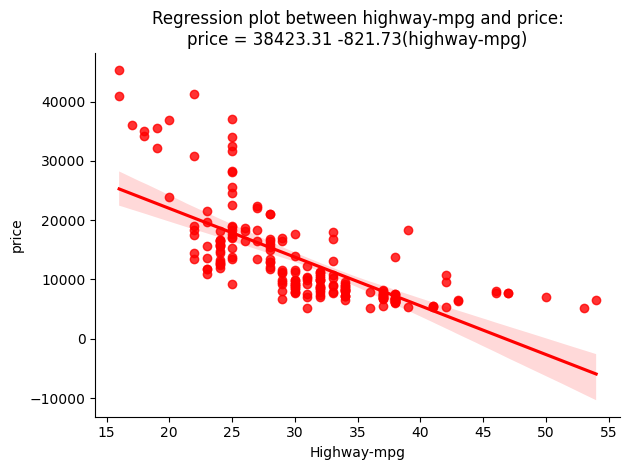

In [92]:
sns.regplot(x = X, y = Y, data = df, color="red")
plt.xlabel("Highway-mpg")
plt.ylabel("price")
plt.title(f"""Regression plot between highway-mpg and price:
price = {b:.2f} {sign}{a:.2f}(highway-mpg)""")
sns.despine()
plt.tight_layout()

<h5>Effect of engine-size on price:</h5>

In [93]:
model_3 = LinearRegression()
X3 = df[["engine-size"]]
Y3 = df["price"]

In [94]:
model_3.fit(X3, Y3)

LinearRegression()

In [95]:
a = model_3.coef_[0]
b = model_3.intercept_
linear_equation_model = f"price = {b:.2f} + {a:.2f}(engine-size)"
print(f"linear equation model: {linear_equation_model}")

linear equation model: price = -7963.34 + 166.86(engine-size)


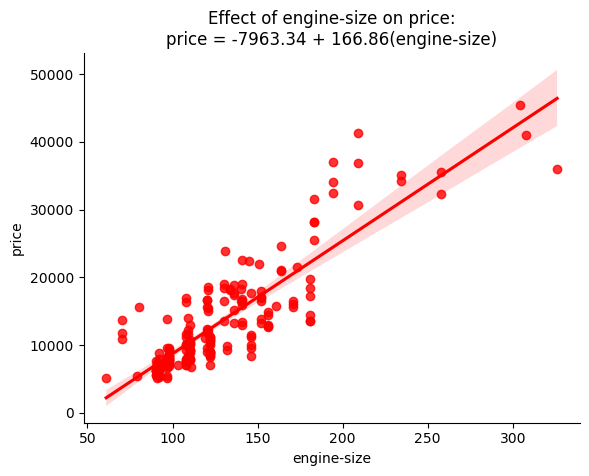

In [96]:
sns.regplot(x = X3, y = Y3, data = df, color ="red")
plt.title(f"""Effect of engine-size on price:
{linear_equation_model}""")
sns.despine()

<h3>Multiple Linear Regression: Prediction</h3>
<p>Y = b + a1(X1) + a2(X2) + a3(X3) + a4(X4)</p>

In [281]:
X4 = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
Y4 = df["price"]
model_4 = LinearRegression()

In [323]:
model_4.fit(X4, Y4)

LinearRegression()

In [104]:
a = model_4.coef_
b = model_4.intercept_
eq_parts = [f"({coef:.2f})*{col}" for coef, col in zip(a, X4.columns)]
multiple_linear_regression_equation = f"{Y4.name} = {b:.2f} + " + " + ".join(eq_parts)
print(multiple_linear_regression_equation)

price = -15806.62 + (53.50)*horsepower + (4.71)*curb-weight + (81.53)*engine-size + (36.06)*highway-mpg


<h4>Multiple Linear Regressions: Inferential Statistics</h4>

In [107]:
import statsmodels.api as sm
import pandas as pd

# Define predictors and target
X4 = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
Y4 = df["price"]

# Add constant for intercept
X4_ols = sm.add_constant(X4)

# Fit the model
model_4 = sm.OLS(Y4, X4_ols).fit()

# Get coefficients, p-values, and confidence intervals
params = model_4.params
pvals = model_4.pvalues
conf = model_4.conf_int()

# Prepare formatted APA-style print
print(f"Regression Results:\n")
print(f"Results of the multiple linear regression indicated that there was a significant effect of the predictors on vehicle price, F({int(model_4.df_model)}, {int(model_4.df_resid)}) = {model_4.fvalue:.2f}, p < .001, R² = {model_4.rsquared:.2f}.\n")

for var in X4_ols.columns:
    if var == 'const':
        continue  # skip intercept in the predictor table
    coef = params[var]
    pval = pvals[var]
    ci_low = conf.loc[var, 0]
    ci_high = conf.loc[var, 1]
    sig = "p < .001" if pval < 0.001 else f"p = {pval:.3f}"
    sig_text = "a significant predictor" if pval <= 0.05 else "not a significant predictor"
    print(f"{var} was {sig_text}, β = {coef:.2f}, {sig}, 95% CI [{ci_low:.2f}, {ci_high:.2f}].")

Regression Results:

Results of the multiple linear regression indicated that there was a significant effect of the predictors on vehicle price, F(4, 196) = 208.02, p < .001, R² = 0.81.

horsepower was a significant predictor, β = 53.50, p < .001, 95% CI [24.45, 82.54].
curb-weight was a significant predictor, β = 4.71, p < .001, 95% CI [2.50, 6.91].
engine-size was a significant predictor, β = 81.53, p < .001, 95% CI [53.79, 109.27].
highway-mpg was not a significant predictor, β = 36.06, p = 0.627, 95% CI [-110.21, 182.32].


<h5>Multicolinearity between predictors</h5>

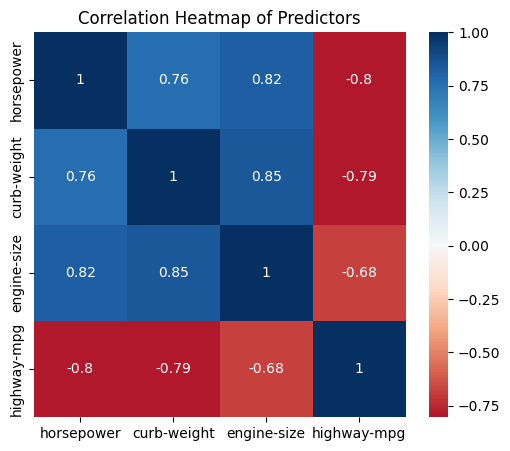

In [108]:
# Select predictors
predictors = ['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']

# Compute correlation matrix
corr_matrix = df[predictors].corr()

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu", center=0)
plt.title("Correlation Heatmap of Predictors")
plt.show()

<p>Heatmap shows high correlations betweens predictors, leading to multicolinearity</p>

<h5>Variance Inflation Factor (VIF)</h5>

<p>VIF tells how much a predictor’s variance is “inflated” due to other predictors. 
High VIF(> 5) suggests problematic multicollinearity.</p>

In [109]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = df[predictors]
X_vif = sm.add_constant(X_vif)  # add intercept

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

       feature         VIF
0        const  315.148830
1   horsepower    4.929610
2  curb-weight    5.455007
3  engine-size    5.557602
4  highway-mpg    4.158980


<ipython-input-113-03bcf309819d>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="VIF", y="feature", data=vif_data[vif_data['feature'] != 'const'], palette="Reds_r", ax=ax2)


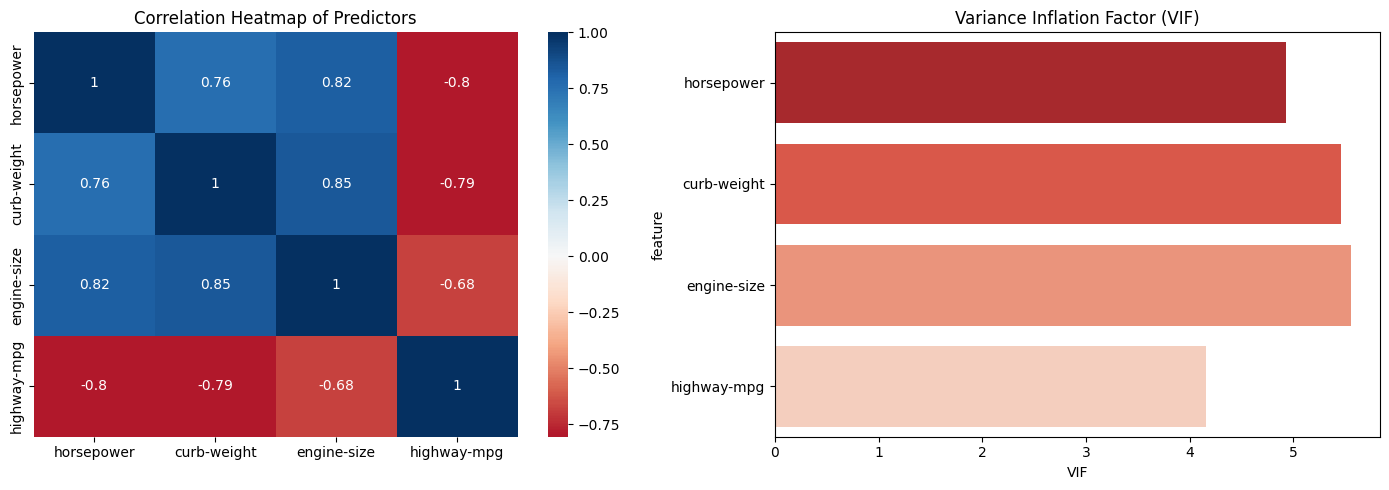

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select predictors
predictors = ['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']

# Compute correlation matrix
corr_matrix = df[predictors].corr()

# Compute VIFs
X_vif = sm.add_constant(df[predictors])
vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

# Create a figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Correlation heatmap
sns.heatmap(corr_matrix, annot=True, cmap="RdBu", center=0, ax=ax1)
ax1.set_title("Correlation Heatmap of Predictors")

# VIF bar plot (skip the constant)
sns.barplot(x="VIF", y="feature", data=vif_data[vif_data['feature'] != 'const'], palette="Reds_r", ax=ax2)
ax2.set_title("Variance Inflation Factor (VIF)")
ax2.set_xlim(0,)  # add a little margin

plt.tight_layout()
plt.show()

<p>Why highway-mpg is no longer significant:</p>
<p>Simple regression: highway-mpg alone explains a lot of variance → highly significant.</p>
<p>Multiple regression: highway-mpg shares variance with engine-size, curb-weight, horsepower → the model “attributes” that variance to the other predictors.</p>
<p>Result: coefficient shrinks, p-value rises → no longer significant.</p>

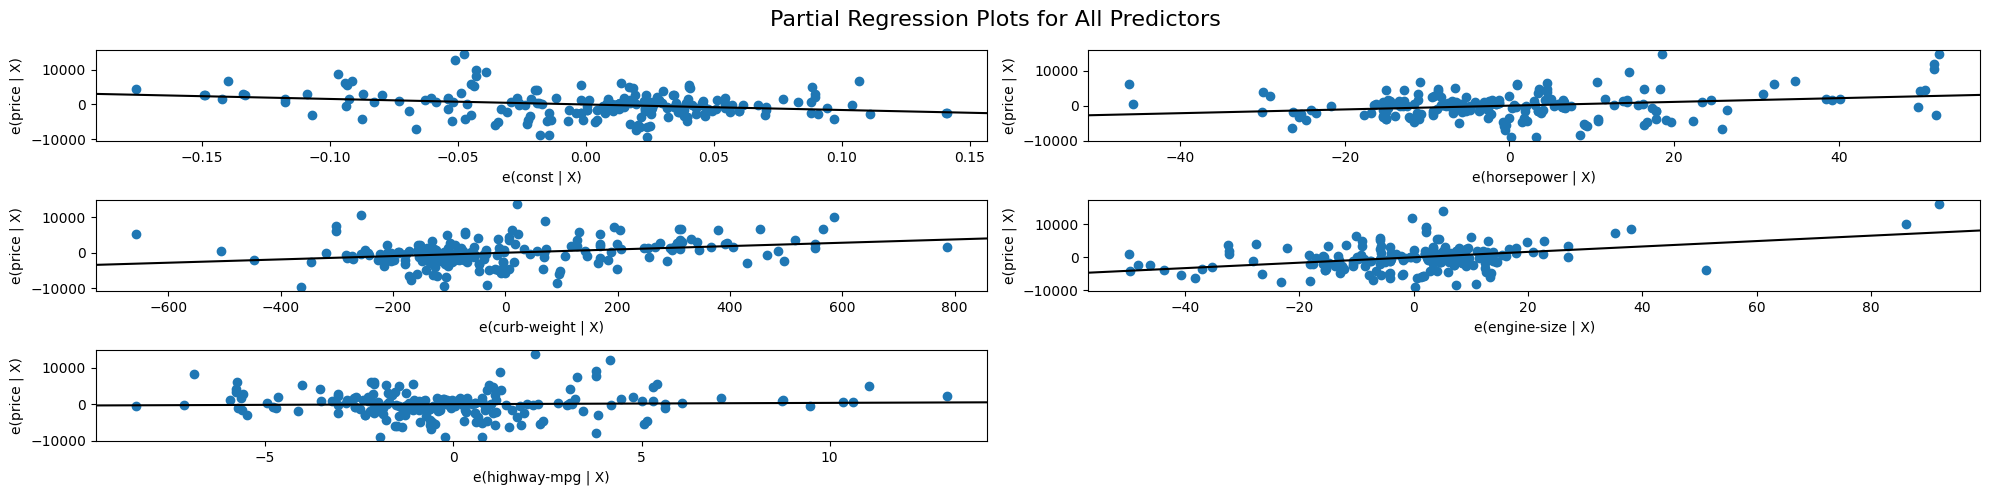

In [120]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Predictors and target
X = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
Y = df['price']

# Add constant
X_sm = sm.add_constant(X)

# Fit multiple regression
model = sm.OLS(Y, X_sm).fit()

# Partial regression plots for all predictors
fig = plt.figure(figsize=(20,5))
sm.graphics.plot_partregress_grid(model, fig=fig)
plt.suptitle("Partial Regression Plots for All Predictors", fontsize=16)
plt.tight_layout()
plt.show()

<h3>Ridge Regression</h3>

In [122]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Predictors and target
X = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
Y = df['price']

# Standardize predictors (important for Ridge)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Ridge regression
ridge = Ridge(alpha=1.0)  # alpha controls regularization strength
ridge.fit(X_scaled, Y)

# Ridge coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Ridge Coefficient': ridge.coef_
})

print(coef_df)

# Predict
Y_pred = ridge.predict(X_scaled)

# Compare R^2
r2_ridge = ridge.score(X_scaled, Y)
print(f"R^2 for Ridge regression: {r2_ridge:.3f}")

       Feature  Ridge Coefficient
0   horsepower        1982.328417
1  curb-weight        2412.002859
2  engine-size        3362.311444
3  highway-mpg         209.804399
R^2 for Ridge regression: 0.809


In [123]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Predictors and target
X = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
Y = df['price']

# --- OLS regression ---
X_ols = sm.add_constant(X)
model_ols = sm.OLS(Y, X_ols).fit()

# OLS results
ols_results = pd.DataFrame({
    'Feature': model_ols.params.index,
    'OLS Coef': model_ols.params.values,
    'OLS Std Err': model_ols.bse.values,
    'OLS t': model_ols.tvalues.values,
    'OLS p-value': model_ols.pvalues.values,
    'OLS 95% CI Lower': model_ols.conf_int()[0],
    'OLS 95% CI Upper': model_ols.conf_int()[1]
})

# --- Ridge regression ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, Y)

# Standardized coefficients for comparison
ridge_coef_std = ridge.coef_ * X.std().values

ridge_results = pd.DataFrame({
    'Feature': X.columns,
    'Ridge Coef (scaled)': ridge_coef_std
})

# Merge OLS and Ridge for comparison
comparison = ols_results.merge(ridge_results, on='Feature', how='left')

# Display
pd.set_option('display.float_format', '{:.2f}'.format)
display(comparison)

,Feature,OLS Coef,OLS Std Err,OLS t,OLS p-value,OLS 95% CI Lower,OLS 95% CI Upper,Ridge Coef (scaled)
0,const,-15806.62,4388.99,-3.60,0.00,-24462.34,-7150.91,NaN
1,horsepower,53.50,14.73,3.63,0.00,24.45,82.54,74071.09
2,curb-weight,4.71,1.12,4.21,0.00,2.50,6.91,1247721.18
3,engine-size,81.53,14.06,5.80,0.00,53.79,109.27,139693.40
4,highway-mpg,36.06,74.17,0.49,0.63,-110.21,182.32,1429.85


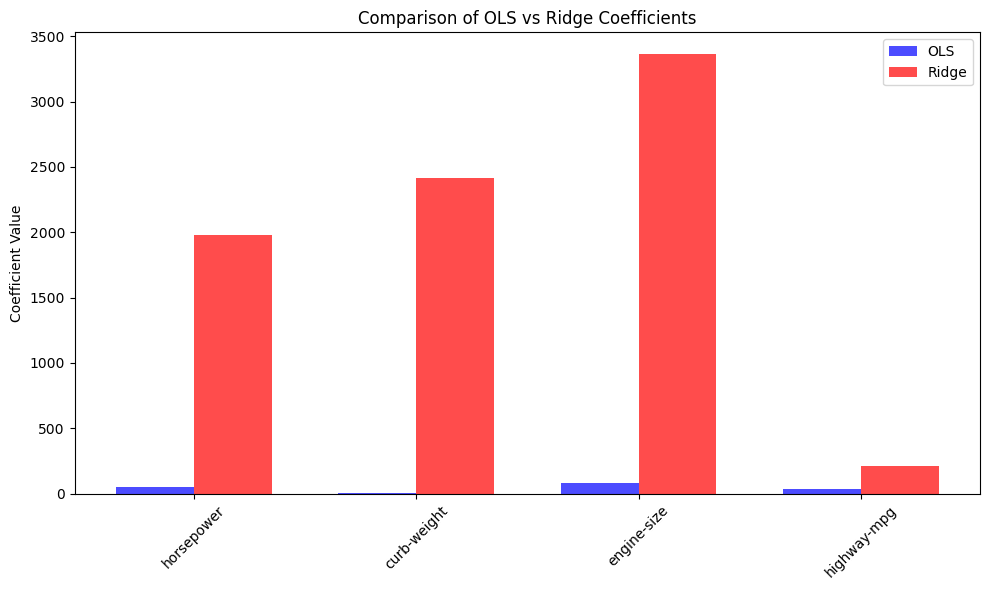

In [126]:
import matplotlib.pyplot as plt
import numpy as np

# --- OLS coefficients ---
ols_coefs = model_ols.params[1:].values  # exclude the constant
features = X.columns

# --- Ridge coefficients ---
ridge_coefs = ridge.coef_

# --- Plot side by side ---
x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, ols_coefs, width, label='OLS', color='blue', alpha=0.7)
plt.bar(x + width/2, ridge_coefs, width, label='Ridge', color='red', alpha=0.7)

plt.xticks(x, features, rotation=45)
plt.ylabel('Coefficient Value')
plt.title('Comparison of OLS vs Ridge Coefficients')
plt.legend()
plt.tight_layout()
plt.show()

<h3>Multiple Linear Regression: Effets of normalized-losses and highway-mpg on price.</h3>
<p> price = a + b1(normalized-losses) + b2(highway-mpg)</p>


In [134]:
X5 = df[["normalized-losses","highway-mpg"]]
Y5 = df["price"]
model5 = LinearRegression()

In [136]:
model5.fit(X5, Y5)

LinearRegression()

In [140]:
model5.coef_
b1 = model5.coef_[0]
b2 = model5.coef_[1]
a = model5.intercept_

In [142]:
print(f"The linear equation: price = {a:.2f} + {b1:.2f}(normalized-losses) + {b2:.2f}(highway-mpg)")

The linear equation: price = 38201.31 + 1.50(normalized-losses) + -820.45(highway-mpg)


<h3>Regression plots:</h3>

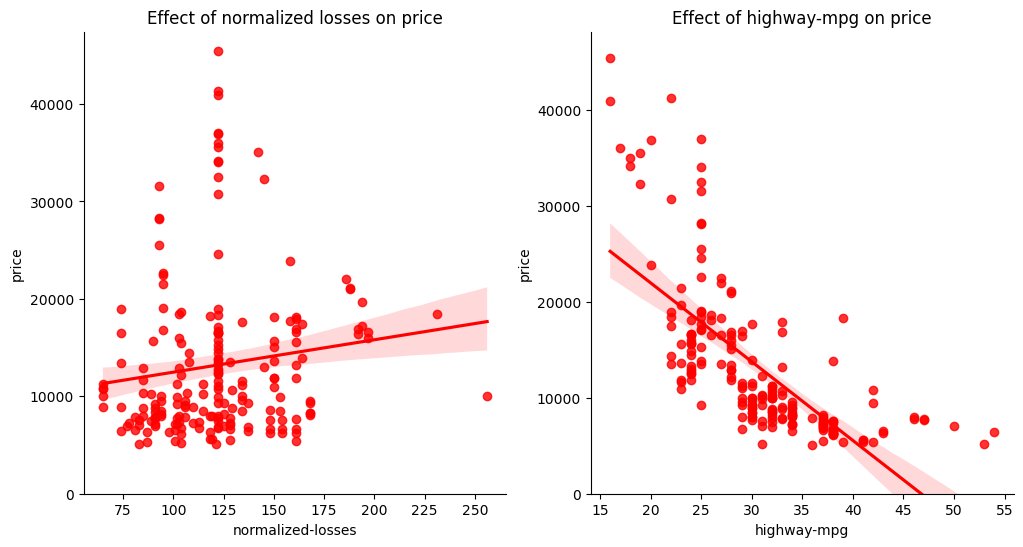

In [172]:
width = 12
height = 6
fig, axes = plt.subplots(1,2,figsize=(width,height))
#plt.figure(figsize=(width,height))
sns.regplot(x = df["normalized-losses"], y = df["price"], data = df, color = "red", ax = axes[0])
sns.despine(ax = axes[0])
axes[0].set_title("Effect of normalized losses on price")
axes[0].set_ylim(0,)

sns.regplot(x = df["highway-mpg"], y = df["price"] , data = df, color = "red" , ax = axes[1])
sns.despine(ax = axes[1])
axes[1].set_title("Effect of highway-mpg on price")
axes[1].set_ylim(0,)

plt.show()

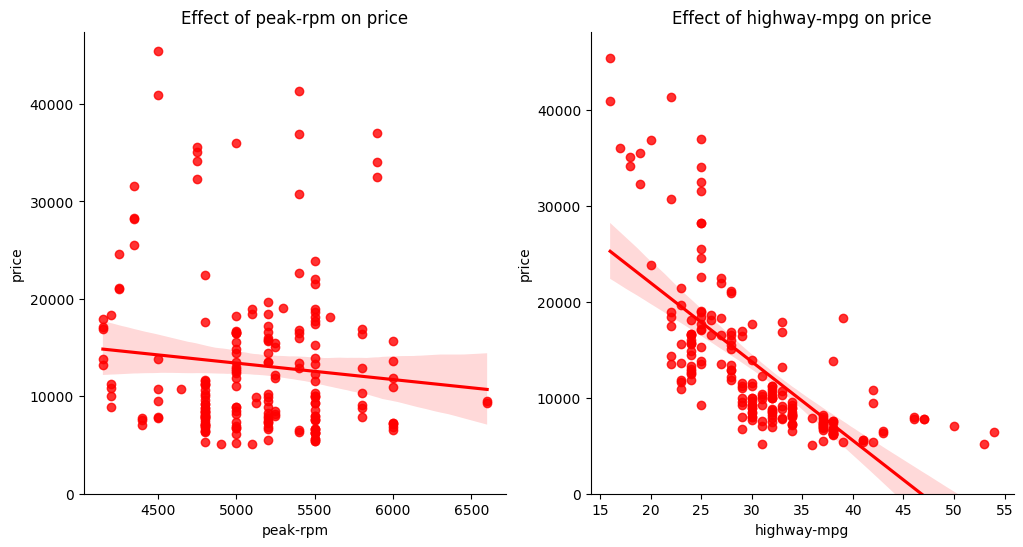

In [173]:
width = 12
height = 6
fig, axes = plt.subplots(1,2,figsize=(width,height))
#plt.figure(figsize=(width,height))
sns.regplot(x = df["peak-rpm"], y = df["price"], data = df, color = "red", ax = axes[0])
sns.despine(ax = axes[0])
axes[0].set_title("Effect of peak-rpm on price")
axes[0].set_ylim(0,)

sns.regplot(x = df["highway-mpg"], y = df["price"] , data = df, color = "red" , ax = axes[1])
sns.despine(ax = axes[1])
axes[1].set_title("Effect of highway-mpg on price")
axes[1].set_ylim(0,)

plt.show()

<h3>Correlations between price and peak-rpm/highway-mpg</h3>

In [180]:
df[["peak-rpm","highway-mpg","price"]].corr()

,peak-rpm,highway-mpg,price
peak-rpm,1.00,-0.06,-0.10
highway-mpg,-0.06,1.00,-0.70
price,-0.10,-0.70,1.00


In [181]:
r_peak_rpm_price = df[["peak-rpm","highway-mpg","price"]].corr().loc["peak-rpm", "price"]
r_highway_mpg_price = df[["peak-rpm","highway-mpg","price"]].corr().loc["highway-mpg", "price"]
print(f"""correlation between peak-rpm and price: r = {r_peak_rpm_price:.2f}
correlation between highway-mpg and price: r = {r_highway_mpg_price:.2f}""")

correlation between peak-rpm and price: r = -0.10
correlation between highway-mpg and price: r = -0.70


<h3>Residual Plot</h3>

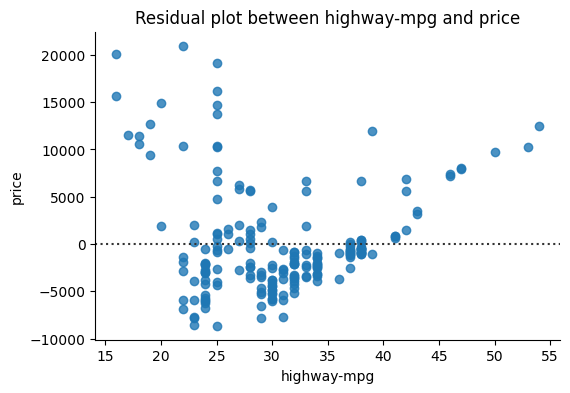

In [191]:
width = 6
height = 4
plt.figure(figsize=(width, height))
sns.residplot(x = df["highway-mpg"], y = df["price"])
sns.despine()
plt.title("Residual plot between highway-mpg and price")
plt.show()

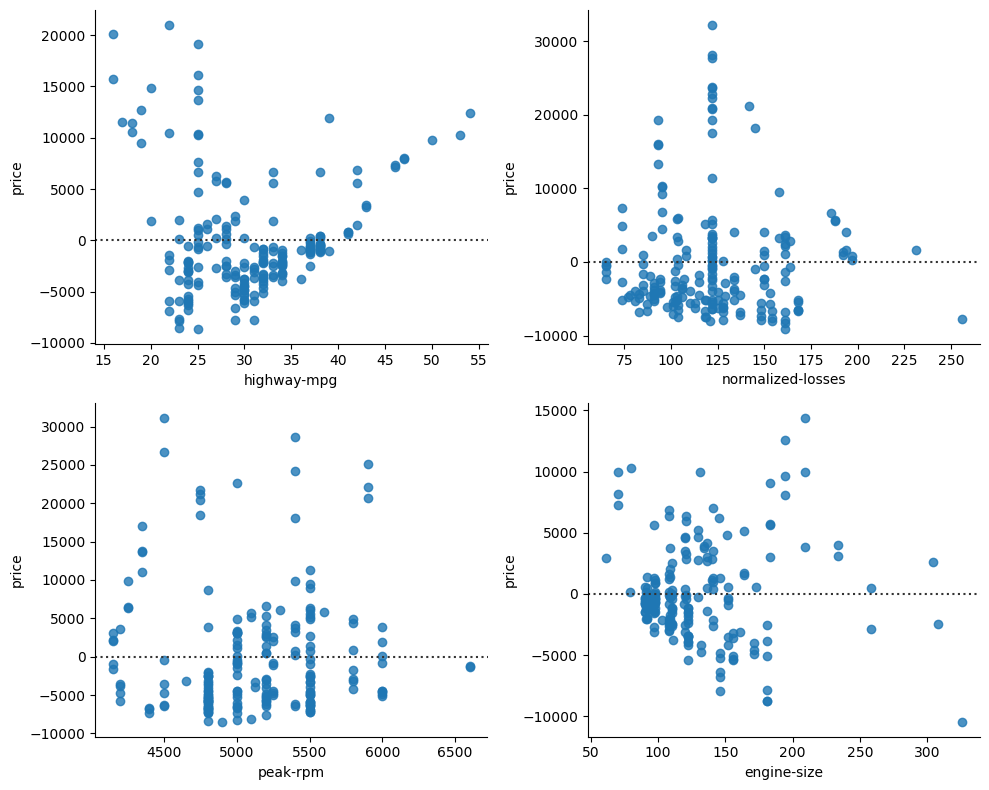

In [210]:
width = 10
height = 8
fig, axes = plt.subplots(2,2, figsize=(width, height))

sns.residplot(x = df["highway-mpg"], y = df["price"], ax = axes[0][0])
sns.residplot(x = df["normalized-losses"], y = df["price"], ax = axes[0][1])
sns.residplot(x = df["peak-rpm"], y = df["price"], ax = axes[1][0])
sns.residplot(x = df["engine-size"], y = df["price"], ax = axes[1][1])
sns.despine(ax = axes[0][0])
sns.despine(ax = axes[0][1])
sns.despine(ax = axes[1][0])
sns.despine(ax = axes[1][1])
plt.tight_layout()

plt.show()

<h3>Distribution Plot for Multiple Linear Regression Model5:</h3>

In [214]:
Y_pred5 = model5.predict(X5)

<ipython-input-232-0b09fabf8a81>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
<ipython-input-232-0b09fabf8a81>:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_pred5, hist=False, color="b", label="Fitted Valu

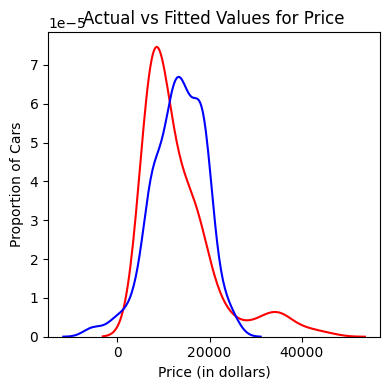

In [232]:
width = 4
height= 4
plt.figure(figsize=(width, height))


ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_pred5, hist=False, color="b", label="Fitted Values" , ax=ax1)


plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.tight_layout()

plt.show()

<h3>Distribution Plot for Multiple Linear Regression Model4:</h3>

In [234]:
X4_bis = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
Y4_bis = df["price"]
model4_bis = LinearRegression()
model4_bis.fit(X4_bis, Y4_bis)

LinearRegression()

In [236]:
Y_pred4_bis = model4_bis.predict(X4_bis)

<ipython-input-237-d3a520b4cc70>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
<ipython-input-237-d3a520b4cc70>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_pred4_bis, hist=False, color="b", label="Fitted 

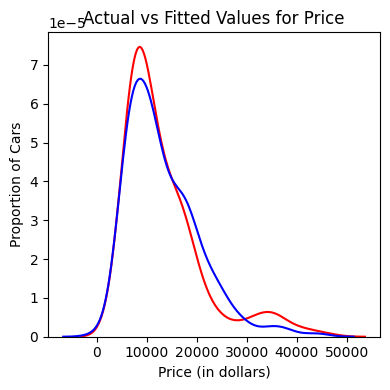

In [237]:
width = 4
height= 4
plt.figure(figsize=(width, height))

ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_pred4_bis, hist=False, color="b", label="Fitted Values" , ax=ax1)


plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.tight_layout()

plt.show()

<h2>Polynomial Regression:</h2>
$$
Y = a + b_1 X +b_2 X^2 +b_3 X^3 ...
$$

In [275]:
def polynomial_plot(model, IV, DV, name_IV):
    x_model = np.linspace(15, 55, 100)
    y_model = model(x_model)

    plt.plot(IV, DV, ".",x_model, y_model, "-")
    plt.title(f"polynomial fit of {name_IV} on price")
    plt.xlabel(name_IV)
    plt.ylabel("price ($)")
    plt.ylim(0,)

    plt.show()
    plt.close()

In [261]:
x = df["highway-mpg"]
y = df ["price"]

In [263]:
# fit a polynomial function of degree 3:
poly3 = np.polyfit(x, y, 3)
polynomial_eq = np.poly1d(poly3)
print(polynomial_eq)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


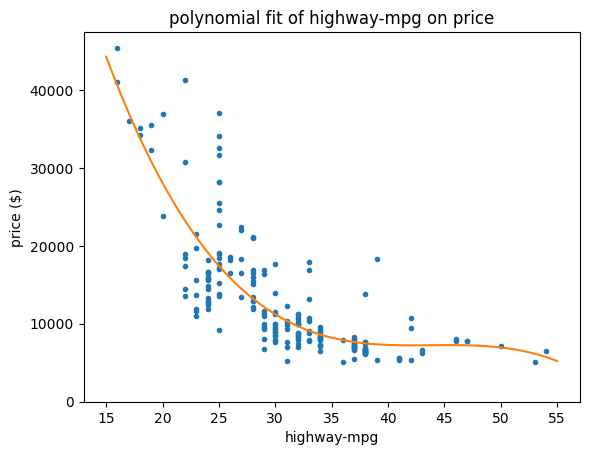

In [276]:
polynomial_plot(polynomial_eq, x, y, "highway-mpg")

<h5>Polynomial function of 11th order:</h5>

In [272]:
poly11 = np.polyfit(x,y,11)
polynomial_eq_11 = np.poly1d(poly11)
print(polynomial_eq_11)

            11             10             9           8         7
-1.243e-08 x  + 4.722e-06 x  - 0.0008028 x + 0.08056 x - 5.297 x
          6        5             4             3             2
 + 239.5 x - 7588 x + 1.684e+05 x - 2.565e+06 x + 2.551e+07 x - 1.491e+08 x + 3.879e+08


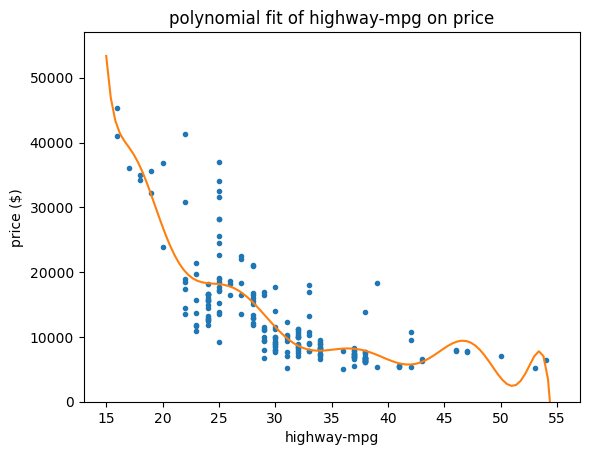

In [277]:
polynomial_plot(polynomial_eq_11, x, y, "highway-mpg")

<h3>Multivariate Polynomial Function of degree 2:</h3>
$$
Y = a + b_1 X_1 +b_2 X_2 +b_3 X_1 X_2+b_4 X_1^2+b_5 X_2^2
$$

In [278]:
from sklearn.preprocessing import PolynomialFeatures

In [280]:
multivariate_poly2 = PolynomialFeatures(degree = 2)
multivariate_poly2

PolynomialFeatures()

In [283]:
#X4 = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
#Y4 = df["price"]
poly_features = multivariate_poly2.fit_transform(X4) #Create the multiple columns features for the equation

In [284]:
X4.shape

(201, 4)

In [289]:
poly_features.shape

(201, 15)

$$
\text{price} =
a
+ b_1(\text{horsepower})
+ b_2(\text{curb-weight})
+ b_3(\text{engine-size})
+ b_4(\text{highway-mpg})
+ b_5(\text{horsepower}^2)
+ b_6(\text{curb-weight}^2)
+ b_7(\text{engine-size}^2)
+ b_8(\text{highway-mpg}^2)
+ b_9(\text{horsepower}\cdot\text{curb-weight})
+ b_{10}(\text{horsepower}\cdot\text{engine-size})
+ b_{11}(\text{horsepower}\cdot\text{highway-mpg})
+ b_{12}(\text{curb-weight}\cdot\text{engine-size})
+ b_{13}(\text{curb-weight}\cdot\text{highway-mpg})
+ b_{14}(\text{engine-size}\cdot\text{highway-mpg})
$$

<h3>Pipeline:</h3>

In [292]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [306]:
Input = [("scale", StandardScaler()),("polynomial",PolynomialFeatures(include_bias=False)),("model",LinearRegression())] 
#list of tuples with name of the model and constructor()
#StandardScaler performs Z-score normalization / standardization.

In [300]:
pipe = Pipeline(Input)
pipe

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [301]:
X4 = X4.astype(float)

In [302]:
pipe.fit(X4,Y4)

Pipeline(steps=[('scale', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [304]:
y_pred_pipe = pipe.predict(X4)
y_pred_pipe[0:10]

array([13102.74784201, 13102.74784201, 18225.54572197, 10390.29636555,
       16136.29619164, 13880.09787302, 15041.58694037, 15457.93465485,
       17974.49032347, 10510.56542385])

<ipython-input-305-a0db5172d961>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
<ipython-input-305-a0db5172d961>:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred_pipe, hist=False, color="b", label="Fitted 

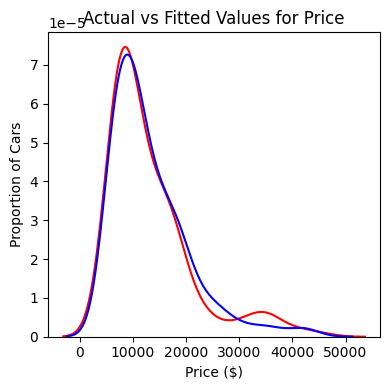

In [305]:
width = 4
height= 4
plt.figure(figsize=(width, height))

ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(y_pred_pipe, hist=False, color="b", label="Fitted Values" , ax=ax1)


plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price ($)')
plt.ylabel('Proportion of Cars')

plt.tight_layout()

plt.show()

<h2>Models Evaluation:</h2>

<h4>Simple Linear Regression: model 1</h4>

In [346]:
X = df[["highway-mpg"]]
Y = df["price"]
R2_1 = model_1.score(X, Y).round(2)
R2_1

0.5

In [347]:
from sklearn.metrics import mean_squared_error
Y_pred_1 = model_1.predict(X)
MSE_1 = mean_squared_error(Y, Y_pred_1).round(2)
MSE_1

31635042.94

In [348]:
print(f"""For the simple Linear Regression model:
R2 = {R2_1}, MSE = {MSE_1}""")

For the simple Linear Regression model:
R2 = 0.5, MSE = 31635042.94


<h4>Multiple Linear Regression: model 2 </h4>

In [349]:
X4 = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
Y4 = df["price"]
R2_2 = model_4.score(X4, Y4).round(2)
R2_2

0.81

In [350]:
Y_pred_4 = model_4.predict(X4)
MSE_2 = mean_squared_error(Y4, Y_pred_4).round(2)
MSE_2

11980366.87

In [351]:
print(f"""For the multiple Linear Regression model:
R2 = {R2_2}, MSE = {MSE_2}""")

For the multiple Linear Regression model:
R2 = 0.81, MSE = 11980366.87


<h4>Polynomial Fit: model 3 </h4>

In [352]:
from sklearn.metrics import r2_score
x = df["highway-mpg"]
y = df ["price"]

R2_3 = r2_score(y, polynomial_eq(x)).round(2)
R2_3

0.67

In [353]:
MSE_3 = mean_squared_error(y,polynomial_eq(x)).round(2)
MSE_3

20474146.43

In [354]:
print(f"""For the polynomial fit:
R2 = {R2_3}, MSE = {MSE_3}""")

For the polynomial fit:
R2 = 0.67, MSE = 20474146.43


<h4>Multivariate polynomial fit of degree 2 : model 4 </h4>

In [355]:
R2_4 = r2_score(Y4, y_pred_pipe).round(2)
R2_4

0.85

In [356]:
MSE_4 = mean_squared_error(Y4, y_pred_pipe).round(2)
MSE_4

9656613.4

In [357]:
print(f"""For the multivariate polynomial fit:
R2 = {R2_4}, MSE = {MSE_4}""")

For the multivariate polynomial fit:
R2 = 0.85, MSE = 9656613.4


<h1>Conclusion</h1>

In [359]:
print(f"""
For the simple Linear Regression model:R2 = {R2_1}, MSE = {MSE_1},
for the multiple Linear Regression model: R2 = {R2_2}, MSE = {MSE_2},
for the polynomial fit: R2 = {R2_3}, MSE = {MSE_3},
for the multivariate polynomial fit: R2 = {R2_4}, MSE = {MSE_4}

The multivariate polynomial model provides the best fit, with the highest R² and lowest MSE, 
but it is less interpretable and may risk overfitting. In contrast, the multiple linear regression model 
offers slightly lower performance but greater interpretability and a reduced likelihood of overfitting.
""")


For the simple Linear Regression model:R2 = 0.5, MSE = 31635042.94,
for the multiple Linear Regression model: R2 = 0.81, MSE = 11980366.87,
for the polynomial fit: R2 = 0.67, MSE = 20474146.43,
for the multivariate polynomial fit: R2 = 0.85, MSE = 9656613.4

The multivariate polynomial model provides the best fit, with the highest R² and lowest MSE, 
but it is less interpretable and may risk overfitting. In contrast, the multiple linear regression model 
offers slightly lower performance but greater interpretability and a reduced likelihood of overfitting.

